# Run this first !
Ensures correct libraries and imports data

In [1]:
# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
    # keep the throwaway Colab clone current; never touch a local working repo
    subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
    subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
                   check=False)
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

# Updated with new data as of 2026-09-30
utt = loading.load(DATA, "all_utterances.csv", "2026-09-30")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-30")
met = loading.load(DATA, "all_metrics.csv", "2026-09-30")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23', '2026-09-30']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows
(2570, 11) (19092, 12) (1021, 6)


In [2]:
# Start timer
import time
start_time = time.time()

# Using John's changes to the exported data

## Link to download data will need to change

In [3]:
# Import structured sentences file
str_sent = pd.read_csv("/Users/rdrobinson/Cambridge/boe-financial-analysis/notebooks/rachel/All_in_one/revised_structured_sentences.csv")
data = str_sent.copy()

In [4]:
# Remove rows where is_filler_sentence = True
data = data[data['is_filler_sentence'] != True]

# Sentence tokenisation

### Import ntlk

In [5]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Speaker Names
Need to remove these from the sentences

In [6]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

[['joseph', 'dickerson'],
 ['christopher', 'mcgratty'],
 ['jim', 'mitchell'],
 ['betsy', 'l.', 'graseck'],
 ['ebrahim', 'h.', 'poonawala'],
 ['mike', 'mayo'],
 ['magdalena', 'stoklosa'],
 ['jamie', 'dimon'],
 ['scott', 'siefers'],
 ['andrew', 'coombs']]

### Tokenising Function

In [7]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        # Removed "greeting words" from the line below:
        if word not in stop_words and word.isalpha() and word and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [8]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(10))

                                             sentence  \
1   Welcome to JPMorgan Chase's First Quarter 2022...   
2                        This call is being recorded.   
3   Your line will be muted for the duration of th...   
4            We will now go live to the presentation.   
6   At this time, I would like to turn the call ov...   
7                        Mr. Barnum, please be ahead.   
10  The presentation is available on our website a...   
11  Starting on page 1, the firm reported net inco...   
12  These results include approximately $900 milli...   
13  Regarding loan growth, we're continuing to see...   

                                         cleaned_text  
1   [welcome, jpmorgan, chase, first, quarter, ear...  
2                                    [call, recorded]  
3                       [line, muted, duration, call]  
4                            [go, live, presentation]  
6   [time, would, like, turn, call, jpmorgan, chas...  
7                                 [m

In [9]:
data.shape



(16513, 16)

# Choose Bank
Amend the commented section to include the bank of choice. Default is set as UBS

In [10]:
# Choose bank name - either UBS or JPM for this work
bank_name = 'JPM'

In [11]:
# Create folder for bank_name specific sentiment classification results
import os

results_folder = f"results_{bank_name}"
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

In [12]:
# Create dataframe with bank = '***' (replace with bank of choice)
data = data[data['bank'] == bank_name].copy()
print(data.shape)
data.head(2)

(8296, 16)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence,cleaned_text
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...,0,Welcome to JPMorgan Chase's First Quarter 2022...,False,"[welcome, jpmorgan, chase, first, quarter, ear..."
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,3,This call is being recorded.,0,This call is being recorded.,False,"[call, recorded]"


## Split by Section to check speakers
Are the same speakers who give the presentation, the same as those who are involved in the Q&A. If so then their language can be directly compared in both

In [13]:
# List all speaker names that are speaker_role = management and section = 'Q&A'
management_qa_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'qa')]['speaker_name'].unique()
print(management_qa_speakers)

['Jeremy Barnum' 'Jamie Dimon']


In [14]:
# List all speaker names that are speaker_role = management and section = "prepared"
management_prepared_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'prepared')]['speaker_name'].unique()
print(management_prepared_speakers)

['Jeremy Barnum' 'Jamie Dimon']


All of the speakers listed as Management in the Q&A session match those in the presentation section and therefore their responses during a scripted presentation vs an open Q&A session can be investigated.

# Bert Emotion: All sections

Truncation = True means only 512 tokens (350 -400 words) are kept. Anything longer is ignored. Also output contains top_k = None so that the scores for all the emotions are retained to allow comparison later on

## Fix colours for emotions

In [15]:
# Fix colours of bars to emotion categories to be used in sns and matplotlib
emotion_palette = {
    'joy': 'darkorange',
    'anger': 'red',
    'sadness': 'dodgerblue',
    'fear': 'purple',
    'surprise': 'green',
    'disgust': 'brown',
    'love': 'deeppink'
}

## Build pipeline

In [16]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8151.52it/s]


## Run the model

In [17]:
# Run the model and keep all emotion scores
basic_emotion = emotion_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
emotion_rows = []
for result in basic_emotion:
    if isinstance(result, list):
        emotion_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        emotion_rows.append({result["label"]: result["score"]})
    else:
        emotion_rows.append({})

# Add the top emotion and score to the dataframe
data["main_emotion"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in emotion_rows
]
data["main_emotion_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in emotion_rows
]

# Add all emotion columns as separate numeric columns
for emotion in ["anger", "joy", "fear", "sadness", "love", "surprise"]:
    data[emotion] = [row.get(emotion, 0.0) for row in emotion_rows]

In [18]:
data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,is_filler_sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,False,"[welcome, jpmorgan, chase, first, quarter, ear...",joy,0.994169,0.000768,0.994169,0.000305,0.002443,0.001968,0.000347
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,False,"[call, recorded]",anger,0.536294,0.536294,0.203670,0.227531,0.013340,0.009466,0.009699


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

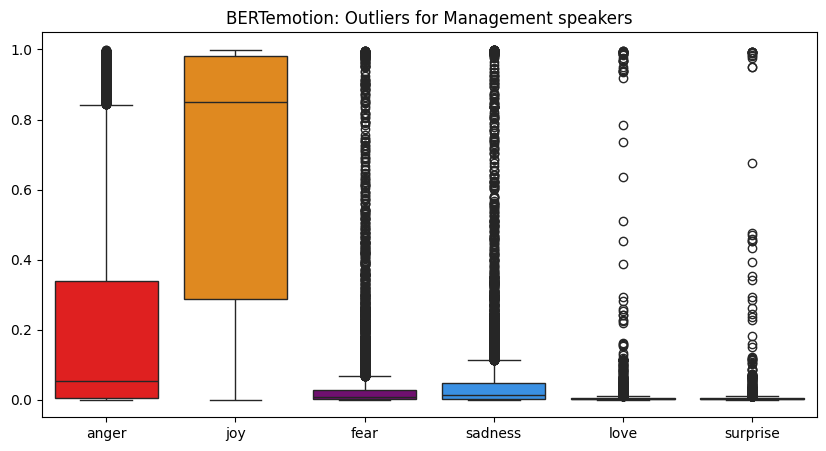

In [19]:
# Look for outliers in emotions of ubs_data where speaker_role = "management"
import seaborn as sns

# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -6:], palette=emotion_palette)
plt.title("BERTemotion: Outliers for Management speakers")
plt.show()

## Calculate quarterly emotion values (Management not Analyst)

In [20]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS)
emotion_stats = data.groupby(["quarter", "main_emotion", "speaker_role","section"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
emotion_stats = emotion_stats[emotion_stats['speaker_role'] != 'analyst']
emotion_stats.head(10)   

,quarter,main_emotion,speaker_role,section,median_score,std_score
1,2022-Q1,anger,management,prepared,0.590989,0.168869
2,2022-Q1,anger,management,qa,0.775702,0.173955
3,2022-Q1,anger,operator,prepared,0.586195,0.070570
4,2022-Q1,anger,operator,qa,0.919689,0.209108
6,2022-Q1,fear,management,prepared,0.995227,0.000000
7,2022-Q1,fear,management,qa,0.788288,0.205140
8,2022-Q1,fear,operator,qa,0.907927,0.000000
10,2022-Q1,joy,management,prepared,0.917361,0.165023
11,2022-Q1,joy,management,qa,0.946283,0.166457
12,2022-Q1,joy,operator,prepared,0.893276,0.153838


In [21]:
# Calculate max and mean values for std_score
emotion_std_max = emotion_stats.groupby('main_emotion')['std_score'].max()
emotion_std_mean = emotion_stats.groupby('main_emotion')['std_score'].mean()
print("Max std_score per emotion:")
print(emotion_std_max)
print("\nMean std_score per emotion:")
print(emotion_std_mean)

Max std_score per emotion:
main_emotion
anger       0.339602
fear        0.433263
joy         0.240235
love        0.183075
sadness     0.304342
surprise    0.430872
Name: std_score, dtype: float64

Mean std_score per emotion:
main_emotion
anger       0.157335
fear        0.150287
joy         0.141375
love        0.029092
sadness     0.172710
surprise    0.092587
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections for all emotions

In [22]:
# Calculate differences between prepared and QA emotion scores for UBS management if NaN use zero
diff_emotion_stats = emotion_stats.pivot_table(index=['quarter', 'main_emotion'], columns='section', values='median_score').reset_index()
diff_emotion_stats = diff_emotion_stats.fillna(0)
diff_emotion_stats['diff'] = diff_emotion_stats['qa'] - diff_emotion_stats['prepared']

In [23]:
# Find max standard deviation from all emotions from emotion_std_max values
all_emotion_std_max = emotion_std_max.max()
print("Value for error bars: ", all_emotion_std_max)

Value for error bars:  0.43326294348992594


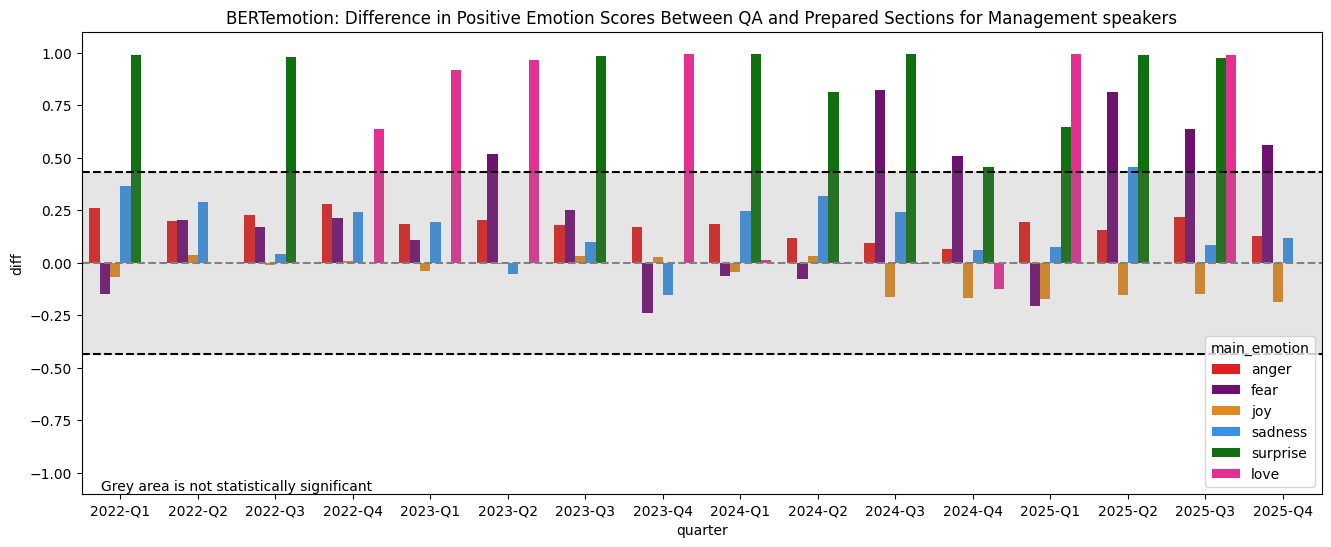

In [24]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=-1.1, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/BERT_emotion_differences_{bank_name}.png")

### Merger period Q2 2022 to Q2 2024

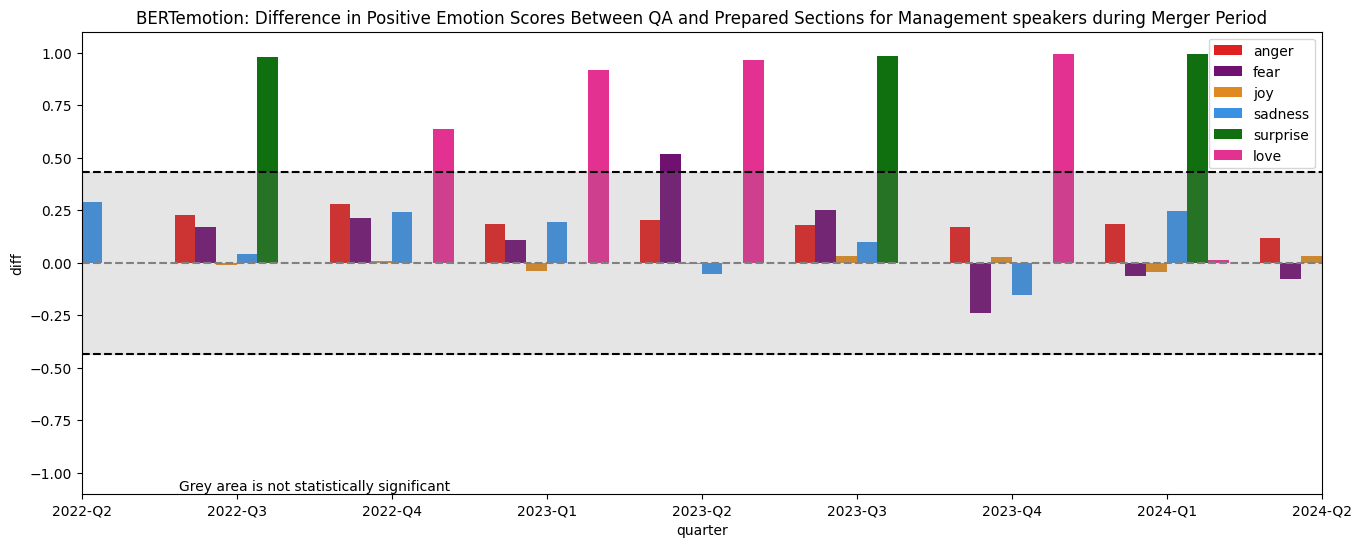

In [25]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

#Set x-lim to include from 2022-Q2 to 2024-Q2
plt.xlim("2022-Q2", "2024-Q2")
# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

# move legend to upper right
plt.legend(loc='upper right')
plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers during Merger Period")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=2.5, 
    y=-1.1, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/BERT_emotion_differences_merge_period_{bank_name}.png")

# FinBERT Model

## Fix colours for sentiments

In [26]:
# Fix colours of bars to sentiment categories to be used in sns and matplotlib
sentiment_palette = {
    # For FinBERT model
    'positive': 'darkorange',
    'neutral': 'grey',
    'negative': 'dodgerblue',

    # For FinBERT-Tone model
    'Positive': 'darkorange',
    'Neutral': 'grey',
    'Negative': 'dodgerblue',

    # For FinBERT-Tone model (which also uses capitalized sentiment labels)
    'FBT_Positive': 'darkorange',
    'FBT_Neutral': 'grey',
    'FBT_Negative': 'dodgerblue',

    # For RoBERTa model
    'RBT_positive': 'darkorange',
    'RBT_neutral': 'grey',
    'RBT_negative': 'dodgerblue',
}

## Build pipeline

In [27]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "prosusai/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 52140.21it/s]


## Run the model

In [28]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["main_sentiment"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in sentiment_rows
]
data["main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["positive", "negative", "neutral"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [29]:

data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,joy,fear,sadness,love,surprise,main_sentiment,main_sentiment_score,positive,negative,neutral
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,0.994169,0.000305,0.002443,0.001968,0.000347,neutral,0.837466,0.144626,0.017908,0.837466
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,0.203670,0.227531,0.013340,0.009466,0.009699,neutral,0.907021,0.037827,0.055152,0.907021
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,0.002711,0.322691,0.027531,0.003867,0.007104,neutral,0.872745,0.027561,0.099694,0.872745
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,0.982614,0.004017,0.003495,0.001337,0.001804,neutral,0.932259,0.033197,0.034545,0.932259
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,0.673268,0.012704,0.044274,0.003811,0.003194,neutral,0.942388,0.027817,0.029794,0.942388
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,0.803937,0.015372,0.010646,0.008209,0.006014,neutral,0.905767,0.063674,0.030560,0.905767
10,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,0.348852,0.035924,0.013858,0.005958,0.004420,neutral,0.950213,0.021989,0.027798,0.950213
11,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38079,...,0.991166,0.000716,0.004978,0.000909,0.000605,neutral,0.862996,0.120126,0.016878,0.862996
12,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38080,...,0.950008,0.004384,0.029824,0.001896,0.001693,neutral,0.886076,0.048319,0.065605,0.886076
13,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38081,...,0.989643,0.000601,0.004062,0.001452,0.000664,positive,0.948119,0.948119,0.016519,0.035362


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

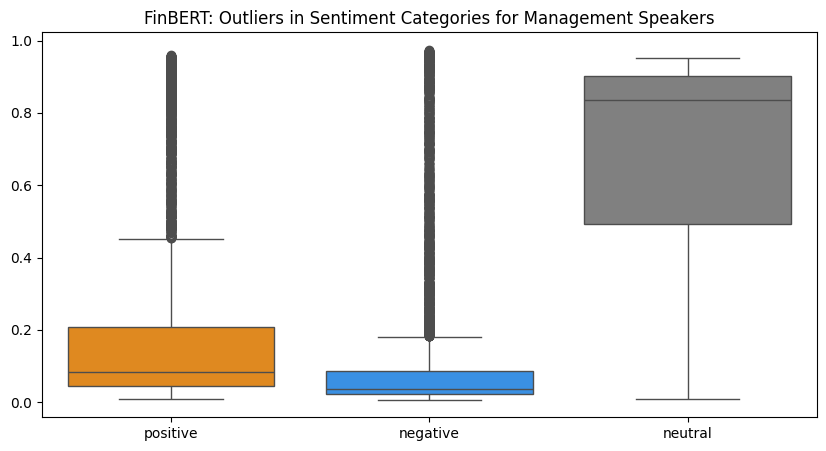

In [30]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -3:], palette=sentiment_palette)
plt.title("FinBERT: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [31]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
sentiment_stats = data.groupby(["quarter", "main_sentiment", "speaker_role","section"]).agg(
    median_score=("main_sentiment_score", "median"),
    std_score=("main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
sentiment_stats = sentiment_stats[sentiment_stats['speaker_role'] != 'analyst']
sentiment_stats.head(10)   

,quarter,main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,negative,management,prepared,0.835449,0.182090
2,2022-Q1,negative,management,qa,0.630199,0.149309
4,2022-Q1,neutral,management,prepared,0.872701,0.141584
5,2022-Q1,neutral,management,qa,0.881489,0.103391
6,2022-Q1,neutral,operator,prepared,0.906394,0.038916
7,2022-Q1,neutral,operator,qa,0.927948,0.081549
9,2022-Q1,positive,management,prepared,0.911970,0.146916
10,2022-Q1,positive,management,qa,0.744897,0.154624
12,2022-Q2,negative,management,prepared,0.828607,0.121631
13,2022-Q2,negative,management,qa,0.777928,0.172275


In [32]:
# Calculate max and mean values for std_score for sentiments
sentiment_std_max = sentiment_stats.groupby('main_sentiment')['std_score'].max()
sentiment_std_mean = sentiment_stats.groupby('main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(sentiment_std_max)
print("\nMean std_score per sentiment:")
print(sentiment_std_mean)

Max std_score per sentiment:
main_sentiment
negative    0.263018
neutral     0.143195
positive    0.176197
Name: std_score, dtype: float64

Mean std_score per sentiment:
main_sentiment
negative    0.156028
neutral     0.082340
positive    0.141519
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [33]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_sentiment_stats = sentiment_stats.pivot_table(index=['quarter', 'main_sentiment'], columns='section', values='median_score').reset_index()
diff_sentiment_stats = diff_sentiment_stats.fillna(0)
diff_sentiment_stats['diff'] = diff_sentiment_stats['qa'] - diff_sentiment_stats['prepared']

In [34]:
diff_sentiment_stats.head(10)

section,quarter,main_sentiment,prepared,qa,diff
0,2022-Q1,negative,0.835449,0.630199,-0.205249
1,2022-Q1,neutral,0.889548,0.904719,0.015171
2,2022-Q1,positive,0.911970,0.744897,-0.167073
3,2022-Q2,negative,0.828607,0.777928,-0.050679
4,2022-Q2,neutral,0.893610,0.882567,-0.011044
5,2022-Q2,positive,0.903642,0.736709,-0.166933
6,2022-Q3,negative,0.849747,0.717875,-0.131872
7,2022-Q3,neutral,0.890804,0.895372,0.004568
8,2022-Q3,positive,0.888154,0.831650,-0.056504
9,2022-Q4,negative,0.889568,0.847716,-0.041852


In [35]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_sentiment_std_max = sentiment_std_max.max()
print("Value for error bars: ", all_sentiment_std_max)

Value for error bars:  0.26301799177882035


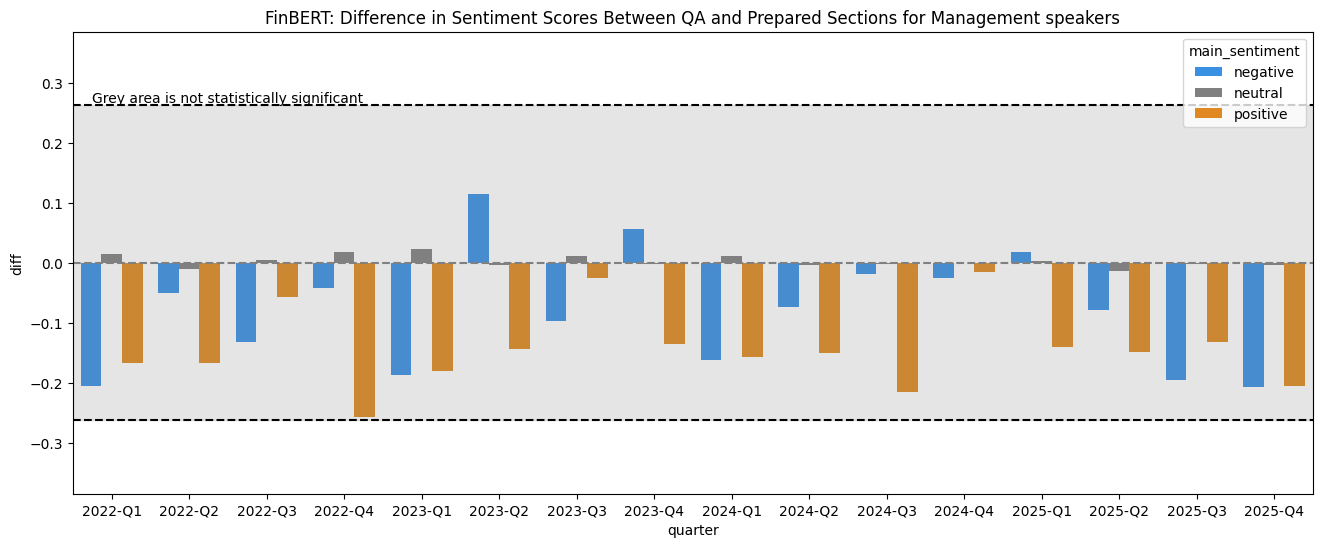

In [36]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/FinBERT_sentiment_differences_{bank_name}.png")

### Merger period Q2 2022 to Q2 2024

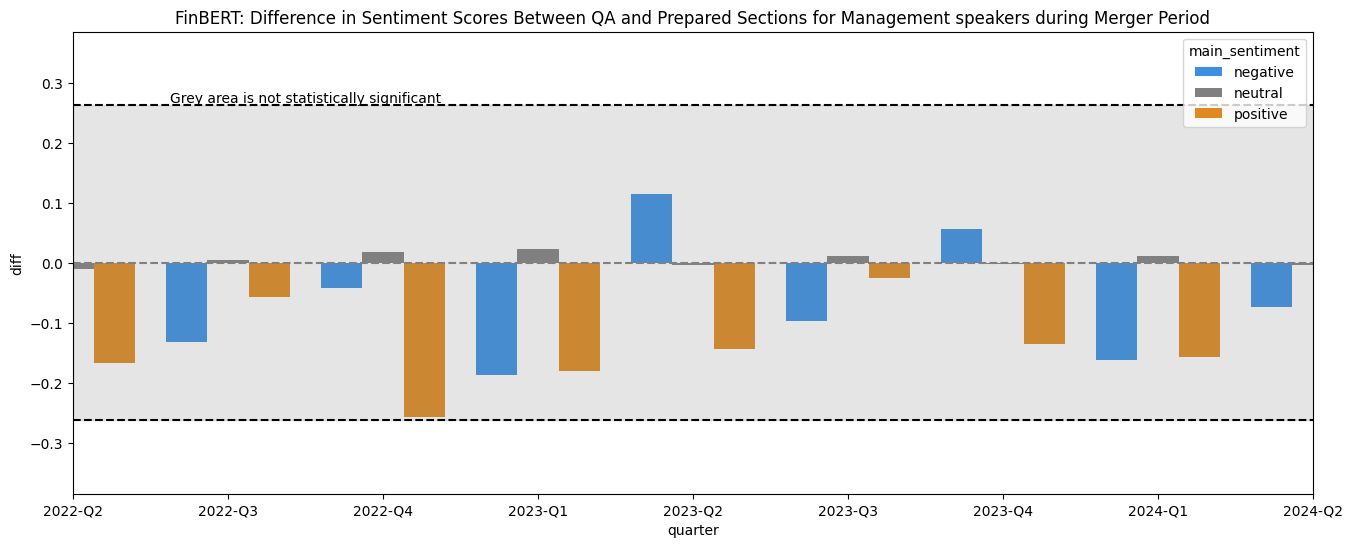

In [37]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

# set x-lim to include from 2022-Q2 to 2024-Q2
plt.xlim("2022-Q2", "2024-Q2")
plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers during Merger Period")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=2.5, 
    y=all_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/FinBERT_sentiment_differences_merge_period_{bank_name}.png")

# Compare FinBERT and BERTemotion

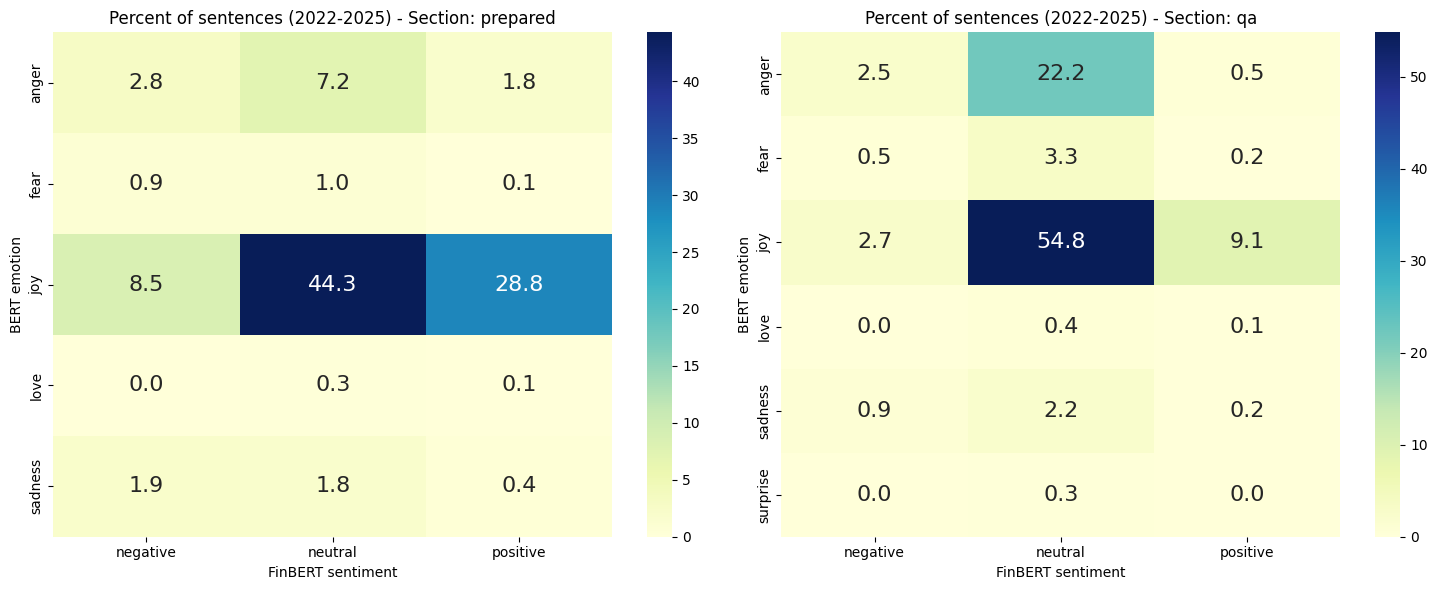

In [38]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# Save figure in bank folder
fig.savefig(f'{results_folder}/BERT_emotion_vs_FinBERT_{bank_name}.png')
plt.show()

# FinBERT-Tone Model

## Build pipeline

In [39]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "yiyanghkust/finbert-tone"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 48989.20it/s]


## Run the model

In [40]:
# Run the model and keep all sentiment scores
basic_FBT_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_FBT_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["FBT_Main_Sentiment"] = [
    max(row, key=row.get, default="Neutral") if row else "Neutral"
    for row in sentiment_rows
]
data["FBT_Main_Sentiment_Score"] = [
    row.get(max(row, key=row.get, default="Neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
# NOTE: FinBERT-Tone requires capital letters for the sentiment labels
for sentiment in ["Positive", "Negative", "Neutral"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [41]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,main_sentiment,main_sentiment_score,positive,negative,neutral,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,Positive,Negative,Neutral
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,neutral,0.837466,0.144626,0.017908,0.837466,Neutral,0.999224,0.000347,4.287062e-04,9.992242e-01
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,neutral,0.907021,0.037827,0.055152,0.907021,Neutral,0.999934,0.000016,5.006634e-05,9.999342e-01
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,neutral,0.872745,0.027561,0.099694,0.872745,Neutral,0.998818,0.000049,1.133684e-03,9.988177e-01
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,neutral,0.932259,0.033197,0.034545,0.932259,Neutral,0.999986,0.000002,1.230122e-05,9.999856e-01
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,neutral,0.942388,0.027817,0.029794,0.942388,Neutral,0.996093,0.000050,3.856973e-03,9.960935e-01
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,neutral,0.905767,0.063674,0.030560,0.905767,Neutral,0.998143,0.000679,1.177751e-03,9.981427e-01
10,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,neutral,0.950213,0.021989,0.027798,0.950213,Neutral,0.997522,0.000070,2.407933e-03,9.975223e-01
11,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38079,...,neutral,0.862996,0.120126,0.016878,0.862996,Neutral,0.999697,0.000226,7.732767e-05,9.996969e-01
12,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38080,...,neutral,0.886076,0.048319,0.065605,0.886076,Neutral,0.999783,0.000039,1.781695e-04,9.997825e-01
13,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38081,...,positive,0.948119,0.948119,0.016519,0.035362,Positive,1.000000,1.000000,1.246612e-09,9.590874e-09


In [42]:
# Update FinBERT-Tone column names to make it clearer
data.rename(
    columns={
        "Positive": "FBT_Positive",
        "Negative": "FBT_Negative",
        "Neutral": "FBT_Neutral",
    },
    inplace=True,
)
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,main_sentiment,main_sentiment_score,positive,negative,neutral,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,neutral,0.837466,0.144626,0.017908,0.837466,Neutral,0.999224,0.000347,4.287062e-04,9.992242e-01
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,neutral,0.907021,0.037827,0.055152,0.907021,Neutral,0.999934,0.000016,5.006634e-05,9.999342e-01
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,neutral,0.872745,0.027561,0.099694,0.872745,Neutral,0.998818,0.000049,1.133684e-03,9.988177e-01
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,neutral,0.932259,0.033197,0.034545,0.932259,Neutral,0.999986,0.000002,1.230122e-05,9.999856e-01
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,neutral,0.942388,0.027817,0.029794,0.942388,Neutral,0.996093,0.000050,3.856973e-03,9.960935e-01
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,neutral,0.905767,0.063674,0.030560,0.905767,Neutral,0.998143,0.000679,1.177751e-03,9.981427e-01
10,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,neutral,0.950213,0.021989,0.027798,0.950213,Neutral,0.997522,0.000070,2.407933e-03,9.975223e-01
11,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38079,...,neutral,0.862996,0.120126,0.016878,0.862996,Neutral,0.999697,0.000226,7.732767e-05,9.996969e-01
12,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38080,...,neutral,0.886076,0.048319,0.065605,0.886076,Neutral,0.999783,0.000039,1.781695e-04,9.997825e-01
13,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38081,...,positive,0.948119,0.948119,0.016519,0.035362,Positive,1.000000,1.000000,1.246612e-09,9.590874e-09


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

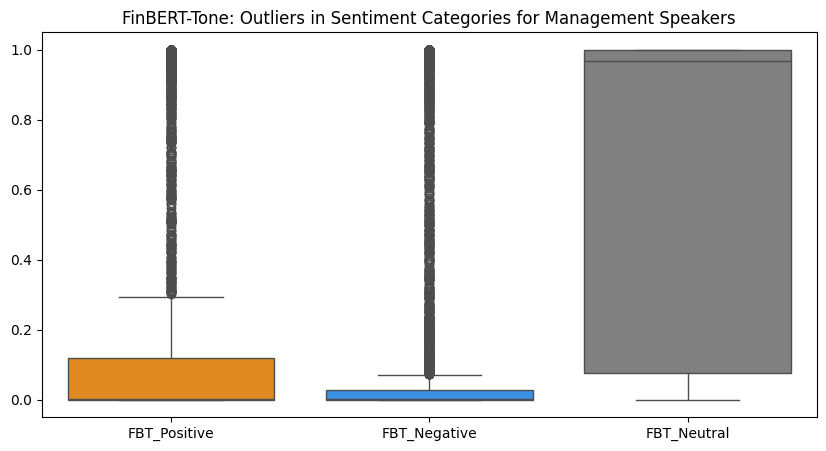

In [43]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
# Use FBT_ columns for the boxplot
sns.boxplot(data=management_data[['FBT_Positive', 'FBT_Negative', 'FBT_Neutral']], palette=sentiment_palette)
plt.title("FinBERT-Tone: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [44]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
FBT_sentiment_stats = data.groupby(["quarter", "FBT_Main_Sentiment", "speaker_role","section"]).agg(
    median_score=("FBT_Main_Sentiment_Score", "median"),
    std_score=("FBT_Main_Sentiment_Score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
FBT_sentiment_stats = FBT_sentiment_stats[FBT_sentiment_stats['speaker_role'] != 'analyst']
FBT_sentiment_stats.head(10)   

,quarter,FBT_Main_Sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,Negative,management,prepared,0.995837,0.058465
2,2022-Q1,Negative,management,qa,0.963808,0.147022
4,2022-Q1,Neutral,management,prepared,0.999587,0.117889
5,2022-Q1,Neutral,management,qa,0.995606,0.112686
6,2022-Q1,Neutral,operator,prepared,0.999021,0.001454
7,2022-Q1,Neutral,operator,qa,0.996725,0.108106
9,2022-Q1,Positive,management,prepared,1.000000,0.057700
10,2022-Q1,Positive,management,qa,0.999935,0.103044
11,2022-Q1,Positive,operator,qa,0.874179,0.000000
13,2022-Q2,Negative,management,prepared,0.999646,0.191319


In [45]:
# Calculate max and mean values for std_score for sentiments
FBT_sentiment_std_max = FBT_sentiment_stats.groupby('FBT_Main_Sentiment')['std_score'].max()
FBT_sentiment_std_mean = FBT_sentiment_stats.groupby('FBT_Main_Sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(FBT_sentiment_std_max)
print("\nMean std_score per sentiment:")
print(FBT_sentiment_std_mean)

Max std_score per sentiment:
FBT_Main_Sentiment
Negative    0.197373
Neutral     0.129697
Positive    0.187728
Name: std_score, dtype: float64

Mean std_score per sentiment:
FBT_Main_Sentiment
Negative    0.133963
Neutral     0.062055
Positive    0.110654
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [46]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_FBT_sentiment_stats = FBT_sentiment_stats.pivot_table(index=['quarter', 'FBT_Main_Sentiment'], columns='section', values='median_score').reset_index()
diff_FBT_sentiment_stats = diff_FBT_sentiment_stats.fillna(0)
diff_FBT_sentiment_stats['diff'] = diff_FBT_sentiment_stats['qa'] - diff_FBT_sentiment_stats['prepared']

In [47]:
diff_FBT_sentiment_stats.head(10)

section,quarter,FBT_Main_Sentiment,prepared,qa,diff
0,2022-Q1,Negative,0.995837,0.963808,-0.032030
1,2022-Q1,Neutral,0.999304,0.996165,-0.003139
2,2022-Q1,Positive,1.000000,0.937057,-0.062943
3,2022-Q2,Negative,0.999646,0.881720,-0.117927
4,2022-Q2,Neutral,0.999341,0.995191,-0.004150
5,2022-Q2,Positive,0.999974,0.999998,0.000024
6,2022-Q3,Negative,0.995687,0.921254,-0.074433
7,2022-Q3,Neutral,0.999085,0.996411,-0.002674
8,2022-Q3,Positive,0.999998,0.999981,-0.000017
9,2022-Q4,Negative,0.978305,0.978486,0.000181


In [48]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_FBT_sentiment_std_max = FBT_sentiment_std_max.max()
print("Value for error bars: ", all_FBT_sentiment_std_max)

Value for error bars:  0.19737271924971816


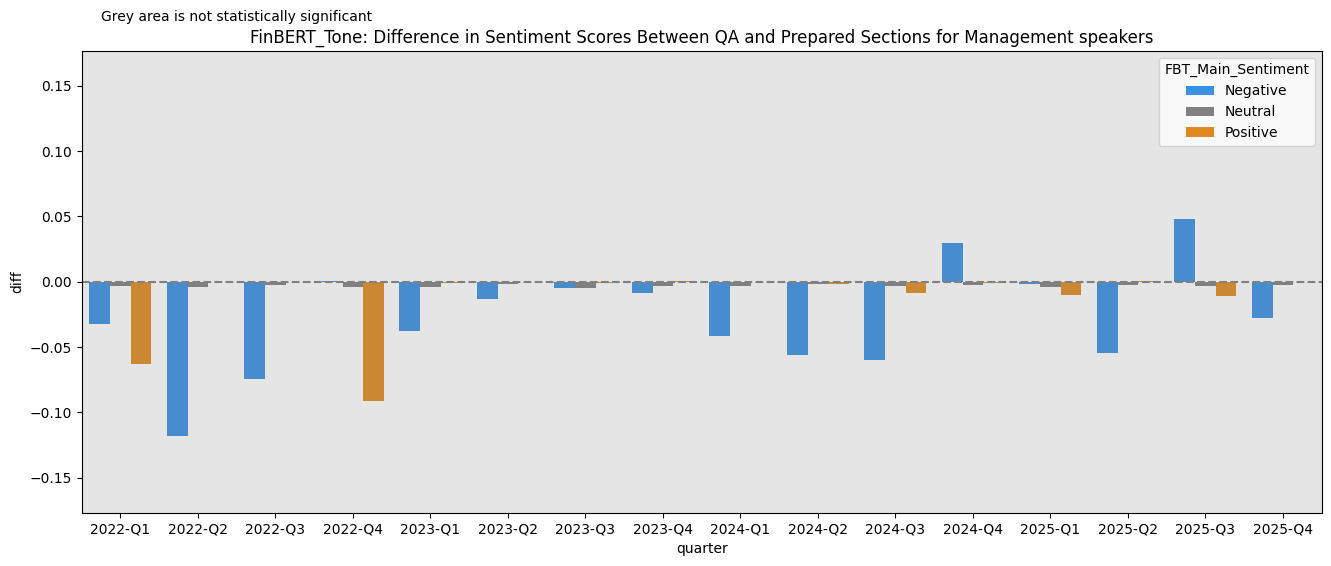

In [49]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_FBT_sentiment_stats, x="quarter", y="diff", hue="FBT_Main_Sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
FBT_diff_range = diff_FBT_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-FBT_diff_range, FBT_diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_FBT_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_FBT_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_FBT_sentiment_std_max,
    all_FBT_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT_Tone: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_FBT_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/FinBERT-Tone_sentiment_differences_{bank_name}.png")

# Compare FinBERT-Tone and BERT-Emotion

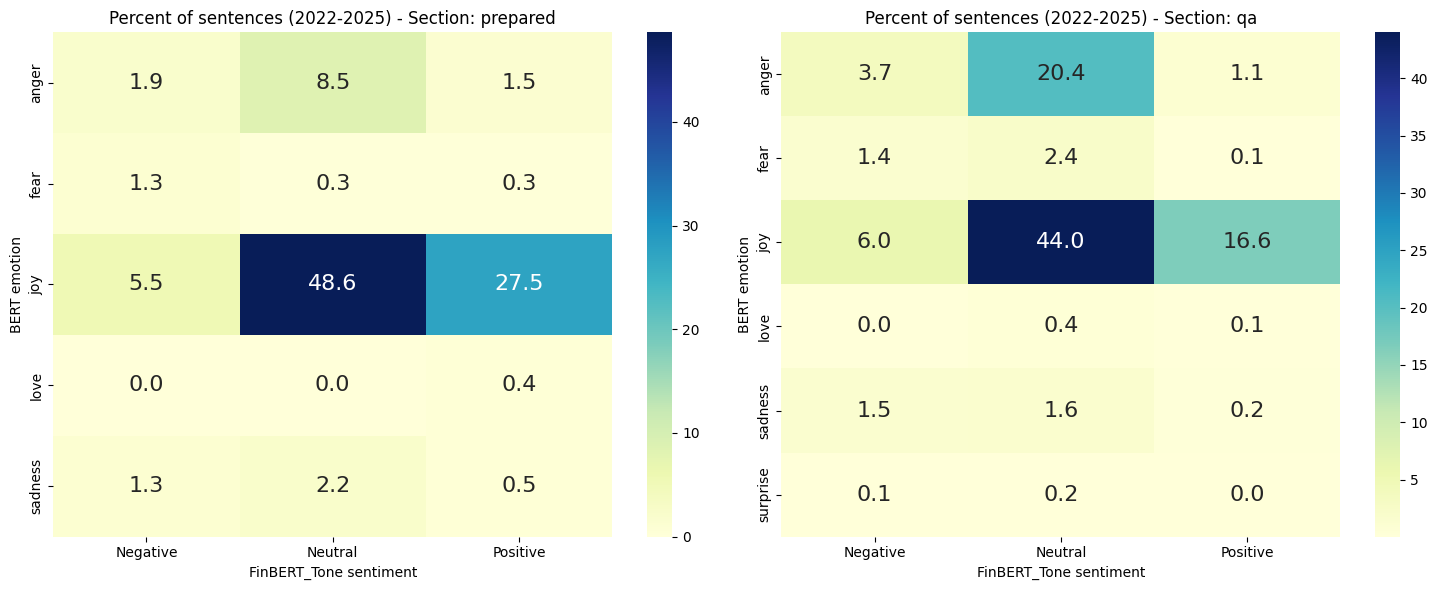

In [50]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT_Tone sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# Save figure in bank folder
fig.savefig(f'{results_folder}/BERT_emotion_vs_FinBERT_Tone_{bank_name}.png')
plt.show()

# Compare FinBERT-Tone and FinBERT

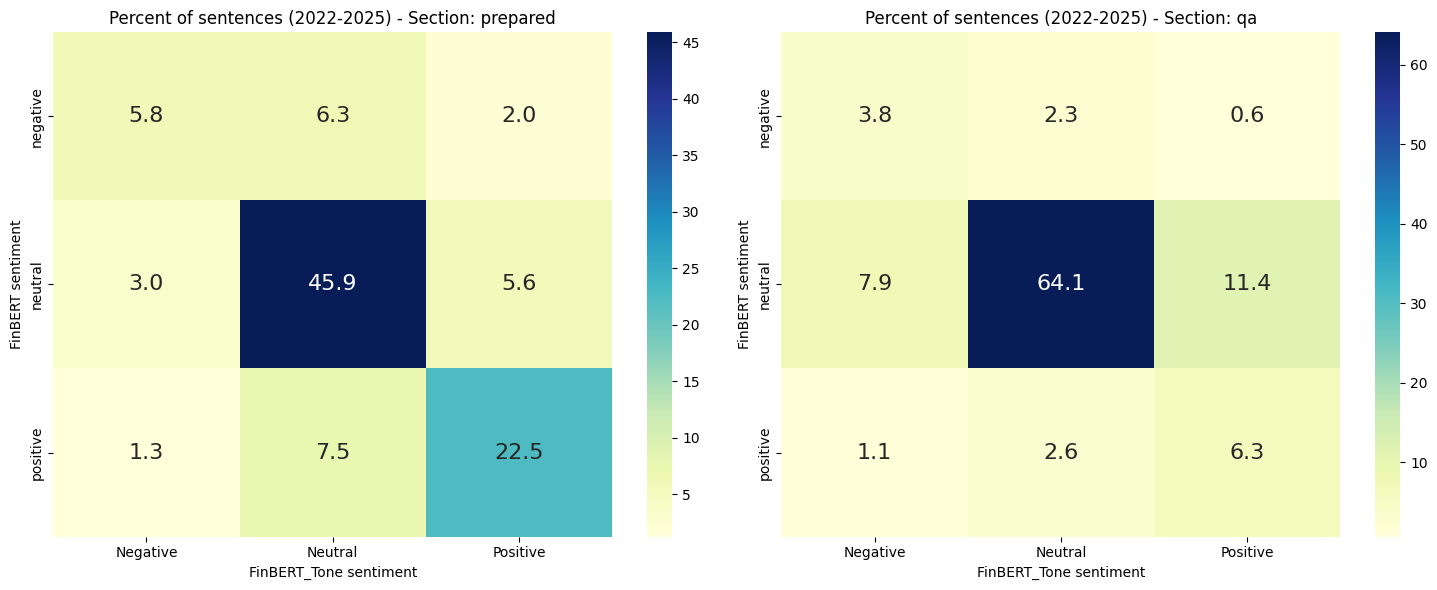

In [51]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT_Tone sentiment')
    axes[i].set_ylabel('FinBERT sentiment')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# Save figure in bank folder
fig.savefig(f'{results_folder}/FinBERT_vs_FinBERT_Tone_{bank_name}.png')
plt.show()

# RoBERTa Model

## Build pipeline

In [52]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Load RoBERTa model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 66903.83it/s]


## Run the model

In [53]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["RBT_main_sentiment"] = [
    max(row, key=row.get, default="LABEL_1") if row else "LABEL_1"
    for row in sentiment_rows
]
data["RBT_main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="LABEL_1"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["LABEL_0", "LABEL_1", "LABEL_2"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]
data.rename(columns={"LABEL_0": "RBT_negative", "LABEL_1": "RBT_neutral", "LABEL_2": "RBT_positive"}, inplace=True)

# Map main_sentiment to "LABEL_0": "negative","LABEL_1": "neutral" and "LABEL_2": "positive"
label_mapping = {
    "LABEL_0": "RBT_negative",
    "LABEL_1": "RBT_neutral",
    "LABEL_2": "RBT_positive",
}
data["RBT_main_sentiment"] = data["RBT_main_sentiment"].map(label_mapping)

In [54]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral,RBT_main_sentiment,RBT_main_sentiment_score,RBT_negative,RBT_neutral,RBT_positive
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,Neutral,0.999224,0.000347,4.287062e-04,9.992242e-01,RBT_positive,0.730632,0.003520,0.265848,0.730632
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,Neutral,0.999934,0.000016,5.006634e-05,9.999342e-01,RBT_neutral,0.727711,0.145285,0.727711,0.127004
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,Neutral,0.998818,0.000049,1.133684e-03,9.988177e-01,RBT_neutral,0.687097,0.270609,0.687097,0.042294
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,Neutral,0.999986,0.000002,1.230122e-05,9.999856e-01,RBT_neutral,0.849775,0.035288,0.849775,0.114936
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,Neutral,0.996093,0.000050,3.856973e-03,9.960935e-01,RBT_neutral,0.897147,0.023675,0.897147,0.079178
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,Neutral,0.998143,0.000679,1.177751e-03,9.981427e-01,RBT_neutral,0.626841,0.041853,0.626841,0.331306
10,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,Neutral,0.997522,0.000070,2.407933e-03,9.975223e-01,RBT_neutral,0.872353,0.049872,0.872353,0.077774
11,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38079,...,Neutral,0.999697,0.000226,7.732767e-05,9.996969e-01,RBT_neutral,0.890833,0.024900,0.890833,0.084267
12,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38080,...,Neutral,0.999783,0.000039,1.781695e-04,9.997825e-01,RBT_neutral,0.904025,0.050316,0.904025,0.045659
13,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38081,...,Positive,1.000000,1.000000,1.246612e-09,9.590874e-09,RBT_positive,0.705291,0.002490,0.292219,0.705291


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

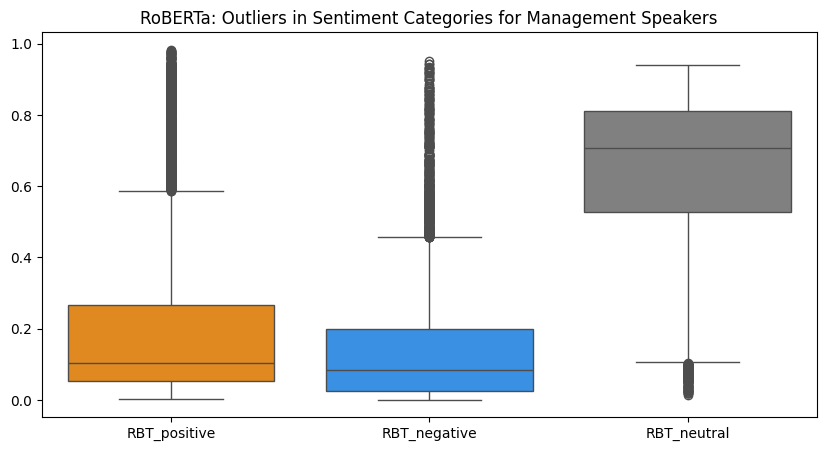

In [55]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
# Use RBT_ columns for the boxplot
sns.boxplot(data=management_data[['RBT_positive', 'RBT_negative', 'RBT_neutral']], palette=sentiment_palette)
plt.title("RoBERTa: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [56]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
RBT_sentiment_stats = data.groupby(["quarter", "RBT_main_sentiment", "speaker_role","section"]).agg(
    median_score=("RBT_main_sentiment_score", "median"),
    std_score=("RBT_main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
RBT_sentiment_stats = RBT_sentiment_stats[RBT_sentiment_stats['speaker_role'] != 'analyst']
RBT_sentiment_stats.head(10)   

,quarter,RBT_main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,RBT_negative,management,prepared,0.564884,0.071156
2,2022-Q1,RBT_negative,management,qa,0.571452,0.149784
4,2022-Q1,RBT_neutral,management,prepared,0.770328,0.121152
5,2022-Q1,RBT_neutral,management,qa,0.718585,0.115636
6,2022-Q1,RBT_neutral,operator,prepared,0.727711,0.112840
7,2022-Q1,RBT_neutral,operator,qa,0.875868,0.089752
9,2022-Q1,RBT_positive,management,prepared,0.704033,0.117086
10,2022-Q1,RBT_positive,management,qa,0.715706,0.158917
11,2022-Q1,RBT_positive,operator,prepared,0.730632,0.000000
12,2022-Q1,RBT_positive,operator,qa,0.933455,0.054531


In [57]:
# Calculate max and mean values for std_score for sentiments
RBT_sentiment_std_max = RBT_sentiment_stats.groupby('RBT_main_sentiment')['std_score'].max()
RBT_sentiment_std_mean = RBT_sentiment_stats.groupby('RBT_main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(RBT_sentiment_std_max)
print("\nMean std_score per sentiment:")
print(RBT_sentiment_std_mean)

Max std_score per sentiment:
RBT_main_sentiment
RBT_negative    0.161256
RBT_neutral     0.125256
RBT_positive    0.167389
Name: std_score, dtype: float64

Mean std_score per sentiment:
RBT_main_sentiment
RBT_negative    0.084987
RBT_neutral     0.100457
RBT_positive    0.083725
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [58]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_RBT_sentiment_stats = RBT_sentiment_stats.pivot_table(index=['quarter', 'RBT_main_sentiment'], columns='section', values='median_score').reset_index()
diff_RBT_sentiment_stats = diff_RBT_sentiment_stats.fillna(0)
diff_RBT_sentiment_stats['diff'] = diff_RBT_sentiment_stats['qa'] - diff_RBT_sentiment_stats['prepared']

In [59]:
diff_RBT_sentiment_stats.head(10)

section,quarter,RBT_main_sentiment,prepared,qa,diff
0,2022-Q1,RBT_negative,0.564884,0.571452,0.006569
1,2022-Q1,RBT_neutral,0.749020,0.797226,0.048207
2,2022-Q1,RBT_positive,0.717332,0.824581,0.107248
3,2022-Q2,RBT_negative,0.564702,0.629905,0.065203
4,2022-Q2,RBT_neutral,0.764377,0.771951,0.007574
5,2022-Q2,RBT_positive,0.667542,0.875497,0.207955
6,2022-Q3,RBT_negative,0.573824,0.635440,0.061615
7,2022-Q3,RBT_neutral,0.756933,0.802043,0.045110
8,2022-Q3,RBT_positive,0.713945,0.861724,0.147779
9,2022-Q4,RBT_negative,0.534180,0.601975,0.067794


In [60]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_RBT_sentiment_std_max = RBT_sentiment_std_max.max()
print("Value for error bars: ", all_RBT_sentiment_std_max)

Value for error bars:  0.1673890922712942


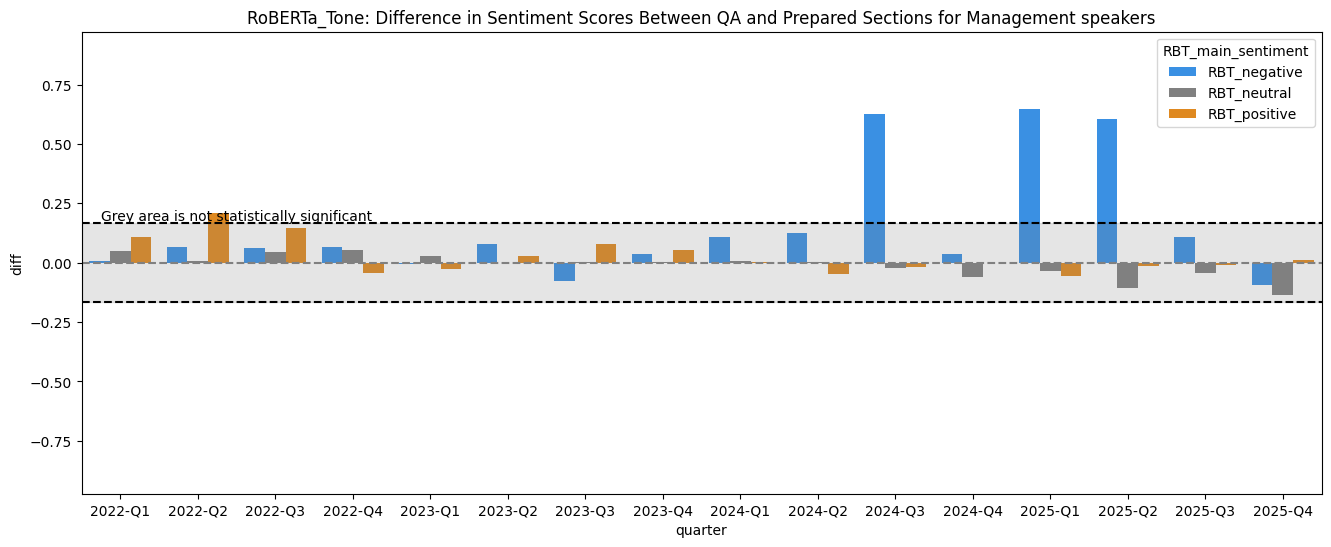

In [61]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_RBT_sentiment_stats, x="quarter", y="diff", hue="RBT_main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_RBT_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_RBT_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_RBT_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_RBT_sentiment_std_max,
    all_RBT_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("RoBERTa_Tone: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_RBT_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/RoBERTa-Tone_sentiment_differences_{bank_name}.png")

# Compare RoBERTa and BERT-Emotion

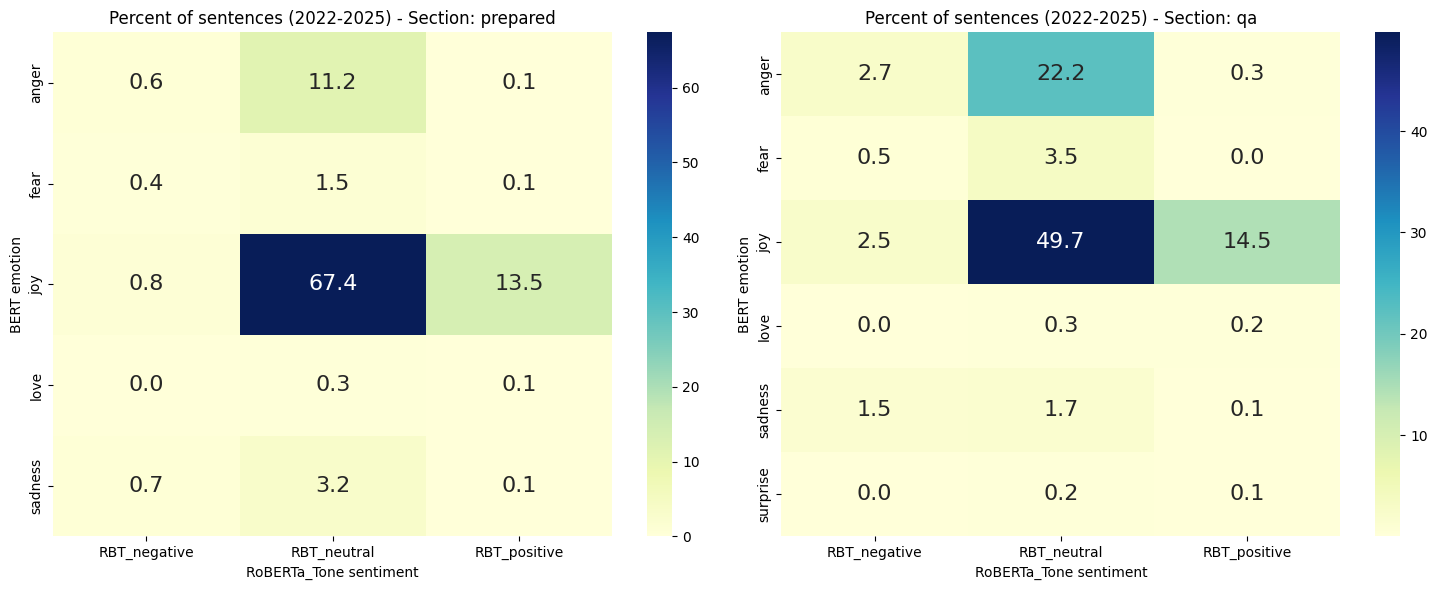

In [62]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'RBT_main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('RoBERTa_Tone sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# save figure in bank folder
fig.savefig(f'{results_folder}/BERT_emotion_vs_RoBERTa_Tone_{bank_name}.png')
plt.show()

# Save Output

In [63]:
# Save output as csv file with bank name in title in bank folder
output_file = f"{results_folder}/sentiment_classification_output_{bank_name}.csv"
data.to_csv(output_file, index=False)
print(f"Output saved to {output_file}")

Output saved to results_JPM/sentiment_classification_output_JPM.csv


# Apply BERTopic to sentences classified as "Negative" by FinBERT

## Sentences where FinBERT = Negative

In [64]:
# Create dataframe with sentences and speakers and quarters but only where main_sentiment = negative

negative_sentences = data[data['main_sentiment'] == 'negative'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
negative_sentences = negative_sentences.sort_values(by=['quarter', 'speaker_role'])

negative_sentences.head(4)

,quarter,speaker_name,speaker_role,sentence,cleaned_text,main_sentiment,main_sentiment_score
110,2022-Q1,John McDonald,analyst,"And as my follow up, could you give us some th...","[follow, could, give, u, thought, market, rela...",negative,0.842683
205,2022-Q1,Steven Chubak,analyst,"In the past, you've spoke about the linkage be...","[past, youve, spoke, linkage, fed, balance, sh...",negative,0.438916
250,2022-Q1,Steven Chubak,analyst,"Jamie, just in the shareholder letter, you had...","[shareholder, letter, spoken, market, underest...",negative,0.603209
270,2022-Q1,Steven Chubak,analyst,And any appetite to deploy the excess liquidity?,"[appetite, deploy, excess, liquidity]",negative,0.727365


## BERTopic Analysis using function to apply to any year

In [65]:
import ast
from bertopic import BERTopic
from umap import UMAP

# Not sure what ast and UMAP actually do !
# ast is used to safely evaluate strings containing Python literals (like lists) into actual Python objects.
# UMAP is a dimensionality reduction technique often used to preprocess data for clustering or topic modeling.

def plot_negative_topics_for_year(data, year, bank=bank_name, min_topic_size=10, top_n_words=3):
    """Run BERTopic on a year's negative sentences and plot topic counts as a bar chart.

    Returns (topic_model, topic_info), or (None, None) if no topics were found.
    """
    year = str(year)
    quarters = [f"{year}-Q{q}" for q in range(1, 5)]

    # Negative sentences for the year
    yr_data = data[(data["main_sentiment"] == "negative") & (data["quarter"].isin(quarters))]

    # Adapt text from "strings of lists" format in csv file, dropping empty sentences
    #texts = [" ".join(ast.literal_eval(t)) for t in yr_data["cleaned_text"]]
    texts = [" ".join(tokens) for tokens in yr_data["cleaned_text"]]
    texts = [t for t in texts if t.strip() != ""]
    print(f"Number of negative sentences for BERTopic modelling in {year}: {len(texts)}")

    topic_model = BERTopic(
        umap_model=UMAP(random_state=42, n_jobs=1),
        min_topic_size=min_topic_size,
        calculate_probabilities=False,
    )
    topic_model.fit_transform(texts)
    topic_info = topic_model.get_topic_info()

    plot_info = topic_info[topic_info["Topic"] != -1].sort_values("Count")  # drop the outlier "topic"
    if plot_info.empty:
        print(f"No topics found for {year} (only outliers); try a smaller min_topic_size.")
        return None, topic_info

    # Shorten names like "0_rates_margin_nii_cost" to "rates, margin, nii"
    labels = [", ".join(name.split("_")[1:1 + top_n_words]) for name in plot_info["Name"]]

    fig, ax = plt.subplots(figsize=(10, 0.45 * len(plot_info) + 1.5))
    bars = ax.barh(labels, plot_info["Count"], color="steelblue")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of negative sentences")
    ax.set_title(f"{bank} negative sentences by BERTopic topic for year = {year}")
    plt.tight_layout()
    plt.show()
    return topic_model, topic_info

Number of negative sentences for BERTopic modelling in 2022: 195


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7365.08it/s]


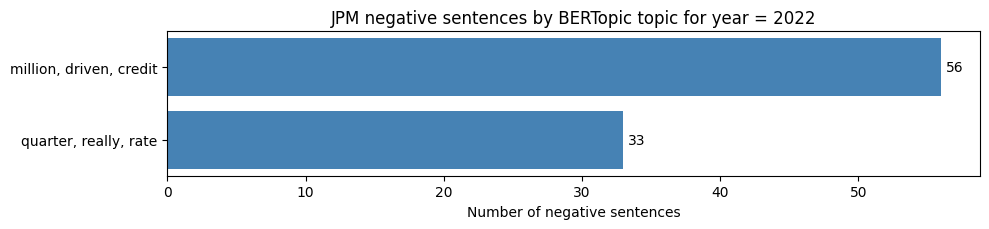

Number of negative sentences for BERTopic modelling in 2023: 181


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 20196.03it/s]


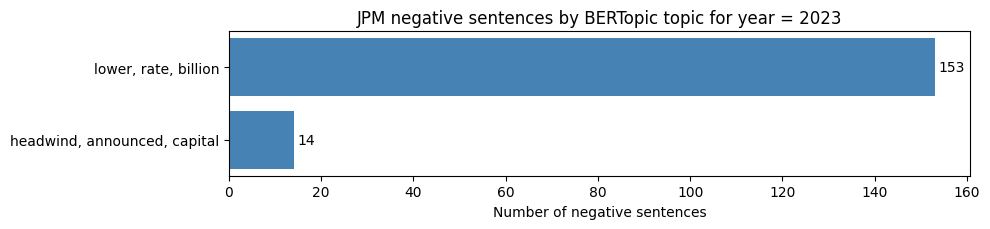

Number of negative sentences for BERTopic modelling in 2024: 130


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 22899.04it/s]


No topics found for 2024 (only outliers); try a smaller min_topic_size.
Number of negative sentences for BERTopic modelling in 2025: 155


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 22578.31it/s]


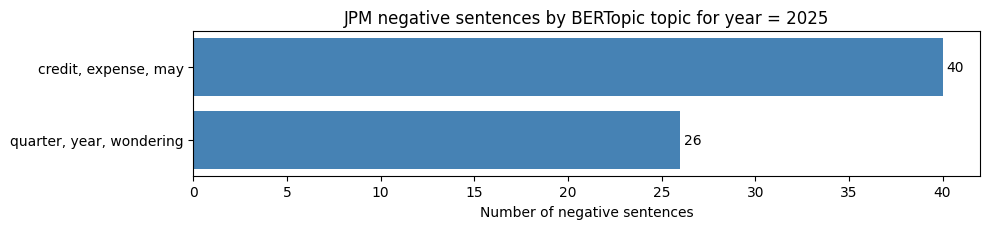

In [66]:
YR_topic_model_22, YR_topic_info_22 = plot_negative_topics_for_year(data, "2022")
YR_topic_model_23, YR_topic_info_23 = plot_negative_topics_for_year(data, "2023")
YR_topic_model_24, YR_topic_info_24 = plot_negative_topics_for_year(data, "2024")
YR_topic_model_25, YR_topic_info_25 = plot_negative_topics_for_year(data, "2025")


In [67]:
# Collect yr_topic_info for all years into one dataframe for plotting, include year as a column
all_YR_topic_info = pd.concat([
    YR_topic_info_22.assign(year="2022"),
    YR_topic_info_23.assign(year="2023"),
    YR_topic_info_24.assign(year="2024"),
    YR_topic_info_25.assign(year="2025")
])
all_YR_topic_info.reset_index(drop=True, inplace=True)

In [68]:
# Add new column for plotting as legend to all_YR_topic_info
# remove numbers and replace underscores with commas
all_YR_topic_info["Legend"] = all_YR_topic_info["Name"].apply(
    lambda x: ", ".join(x.split("_")[1:])
)
all_YR_topic_info.head()


,Topic,Count,Name,Representation,Representative_Docs,year,Legend
0,-1,106,-1_billion_loss_lower_market,"[billion, loss, lower, market, balance, nii, y...",[nii billion billion yearonyear due impact hig...,2022,"billion, loss, lower, market"
1,0,56,0_million_driven_credit_activity,"[million, driven, credit, activity, market, ca...",[gross investment banking revenue million year...,2022,"million, driven, credit, activity"
2,1,33,1_quarter_really_rate_year,"[quarter, really, rate, year, higher, early, p...",[today guidance fourth quarter year implies ap...,2022,"quarter, really, rate, year"
3,-1,14,-1_million_billion_net_may,"[million, billion, net, may, nii, ear, problem...",[nii billion billion yearonyear due impact hig...,2023,"million, billion, net, may"
4,0,153,0_lower_rate_billion_higher,"[lower, rate, billion, higher, quarter, deposi...",[nii billion billion yearonyear due impact hig...,2023,"lower, rate, billion, higher"


## BERTopic - final plot

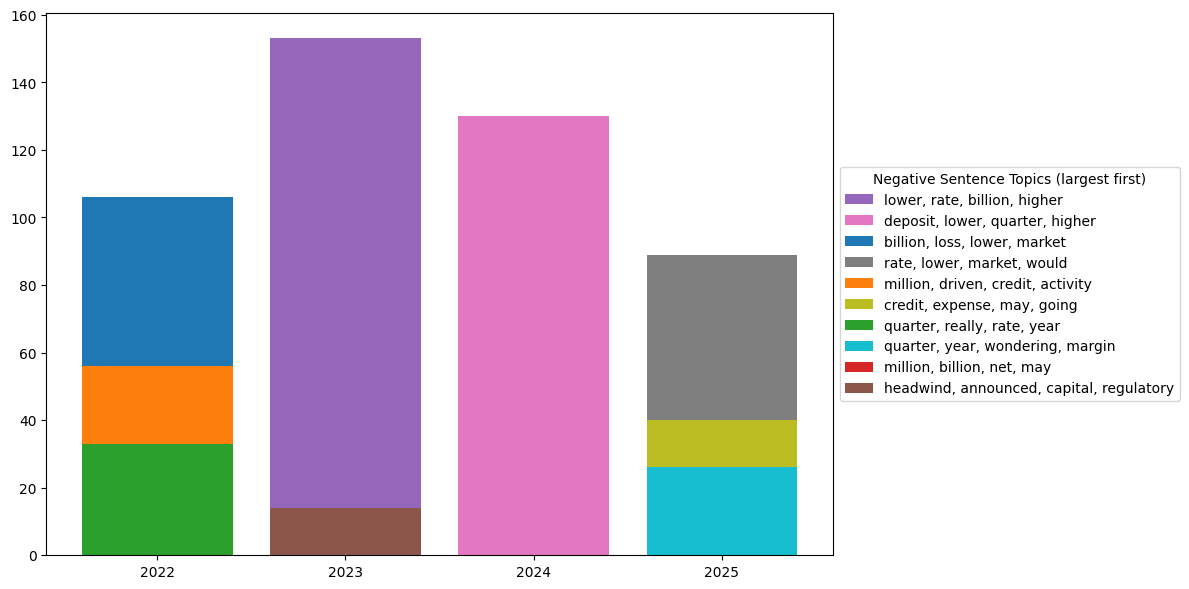

In [69]:

fig, ax = plt.subplots(figsize=(12, 6))

for topic in all_YR_topic_info["Name"].unique():
    topic_data = all_YR_topic_info[all_YR_topic_info["Name"] == topic]
    ax.bar(topic_data["year"], topic_data["Count"], label=topic_data["Legend"].iloc[0])

# Total count per legend label, used for ordering
totals = all_YR_topic_info.groupby("Legend")["Count"].sum()

handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: totals[labels[i]], reverse=True)

ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="center left",
    bbox_to_anchor=(1, 0.5),   # legend at the side
    title="Negative Sentence Topics (largest first)",
)
plt.tight_layout()
# save figure in bank folder
plt.savefig(f"{results_folder}/negative_sentence_topics_by_year_for_{bank_name}.png")
plt.show()

# Check run times

In [70]:
# End timer and print elapsed time in minutes to 2 significant figures
end_time = time.time()
print("Elapsed time: ", round((end_time - start_time)/60, 2), "minutes")

Elapsed time:  7.66 minutes
